In [33]:
# ============================================================
# AUREX - ADAPTIVE PIPELINE (SARIMAX + IMPROVED HURDLE)
# Works with PostgreSQL daily_sales + products
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import pearsonr

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")


# -----------------------------
# 1) DB LOADERS
# -----------------------------
def load_product_sales(conn, product_id: int):
    """
    Returns a daily DataFrame with:
    sale_date, units_sold, unit_price, total_revenue, product_name, category, is_seasonal
    Ensures continuous daily index (fills missing dates).
    """
    q = """
    SELECT
        d.sale_date::date AS sale_date,
        d.units_sold::float AS units_sold,
        d.unit_price::float AS unit_price,
        d.total_revenue::float AS total_revenue,
        p.product_name,
        p.category,
        p.is_seasonal
    FROM daily_sales d
    JOIN products p ON p.product_id = d.product_id
    WHERE d.product_id = %s
    ORDER BY d.sale_date;
    """
    df = pd.read_sql(q, conn, params=(product_id,))
    if df.empty:
        raise ValueError(f"No data found for product_id={product_id}")

    df["sale_date"] = pd.to_datetime(df["sale_date"])
    df = df.sort_values("sale_date").reset_index(drop=True)

    # Build full daily range and fill missing days
    full_idx = pd.date_range(df["sale_date"].min(), df["sale_date"].max(), freq="D")
    df = df.set_index("sale_date").reindex(full_idx)
    df.index.name = "sale_date"

    # Keep static product metadata
    for c in ["product_name", "category", "is_seasonal"]:
        df[c] = df[c].ffill().bfill()

    # Fill numeric columns
    df["units_sold"] = df["units_sold"].fillna(0.0)
    df["unit_price"] = df["unit_price"].ffill().bfill()
    df["total_revenue"] = df["total_revenue"].fillna(df["units_sold"] * df["unit_price"])

    return df.reset_index()


# -----------------------------
# 2) FEATURE ENGINEERING
# -----------------------------
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["dow"] = df["sale_date"].dt.dayofweek
    df["month"] = df["sale_date"].dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    # Cyclical encoding
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)
    return df


def _days_since_last_sale_from_history(history_vals):
    """
    history_vals: array of historical units (typically y shifted by 1 day).
    """
    out = []
    c = 0
    for v in history_vals:
        if np.isnan(v):
            out.append(0)
            continue
        if v > 0:
            c = 0
        else:
            c += 1
        out.append(c)
    return out


def add_temporal_memory(df: pd.DataFrame, y_col="units_sold") -> pd.DataFrame:
    """
    IMPORTANT: all temporal features are based on past information only
    (using shift(1)) to avoid target leakage.
    """
    df = df.copy()
    y_hist = df[y_col].shift(1)  # yesterday and earlier only

    # Lags
    df["lag_1"] = y_hist
    df["lag_7"] = df[y_col].shift(7)
    df["lag_14"] = df[y_col].shift(14)
    df["lag_28"] = df[y_col].shift(28)

    # Rolling means from history only
    df["ma_7"] = y_hist.rolling(7, min_periods=1).mean()
    df["ma_14"] = y_hist.rolling(14, min_periods=1).mean()
    df["ma_30"] = y_hist.rolling(30, min_periods=1).mean()

    # Rolling std from history only
    df["std_7"] = y_hist.rolling(7, min_periods=1).std().fillna(0)

    # Days since last sale using history only
    df["days_since_sale"] = _days_since_last_sale_from_history(y_hist.values)

    df["sold_yesterday"] = (df["lag_1"].fillna(0) > 0).astype(int)
    df["trend_7"] = (df["ma_7"] - df["ma_7"].shift(7)).fillna(0)
    return df


def build_matrix(df: pd.DataFrame):
    feature_cols = [
        "unit_price",
        "is_weekend",
        "month_sin", "month_cos",
        "dow_sin", "dow_cos",
        "lag_1", "lag_7", "lag_14", "lag_28",
        "ma_7", "ma_14", "ma_30",
        "std_7",
        "days_since_sale",
        "sold_yesterday",
        "trend_7"
    ]
    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    y = df["units_sold"].astype(float).values
    dates = df["sale_date"].copy()
    return X, y, dates, feature_cols


# -----------------------------
# 3) BEHAVIORAL METRICS (Dr. Yow focus)
# -----------------------------
def detect_peaks_score(y_true, y_pred, prominence=None, tol_days=3):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if prominence is None:
        prominence = (y_true.max() - y_true.min()) * 0.2 if len(y_true) else 0.0

    peaks_true, _ = signal.find_peaks(y_true, prominence=prominence)
    peaks_pred, _ = signal.find_peaks(y_pred, prominence=prominence)

    if len(peaks_true) == 0:
        return 1.0, 0, 0

    detected = 0
    for pt in peaks_true:
        if any(abs(pp - pt) <= tol_days for pp in peaks_pred):
            detected += 1

    return detected / len(peaks_true), len(peaks_true), detected


def trend_corr(y_true, y_pred, window=7):
    if len(y_true) < window + 2:
        return np.nan
    t1 = np.diff(pd.Series(y_true).rolling(window, min_periods=1).mean())
    t2 = np.diff(pd.Series(y_pred).rolling(window, min_periods=1).mean())
    ok = ~(np.isnan(t1) | np.isnan(t2))
    if ok.sum() < 2:
        return np.nan
    return pearsonr(t1[ok], t2[ok])[0]


def direction_acc(y_true, y_pred):
    if len(y_true) < 2:
        return np.nan
    c1 = np.diff(y_true)
    c2 = np.diff(y_pred)
    return (np.sign(c1) == np.sign(c2)).mean()


def shape_similarity(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    yt = (y_true - y_true.min()) / (y_true.max() - y_true.min() + 1e-8)
    yp = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min() + 1e-8)
    mad = np.mean(np.abs(yt - yp))
    return max(0, 1 - mad)


def behavioral_summary(y_true, y_pred):
    peak, nreal, ndet = detect_peaks_score(y_true, y_pred)
    tc = trend_corr(y_true, y_pred)
    da = direction_acc(y_true, y_pred)
    ss = shape_similarity(y_true, y_pred)

    pred_std = float(np.std(y_pred))
    true_std = float(np.std(y_true))
    vr = pred_std / true_std if true_std > 0 else 0

    return dict(
        peak_detection_rate=peak,
        n_peaks_real=nreal,
        n_peaks_detected=ndet,
        trend_correlation=tc,
        direction_accuracy=da,
        shape_similarity=ss,
        variance_ratio=vr,
        pred_std=pred_std,
        true_std=true_std
    )


# -----------------------------
# 4) DIAGNOSTICS + MODEL CHOICE
# -----------------------------
def _max_zero_streak(y):
    max_streak = 0
    cur = 0
    for v in y:
        if v == 0:
            cur += 1
            if cur > max_streak:
                max_streak = cur
        else:
            cur = 0
    return int(max_streak)


def diagnose_series(y):
    y = np.asarray(y)
    n = len(y)
    n_nonzero = int((y > 0).sum())
    zero_rate = float((y == 0).mean()) if n else 0.0
    max_zero_streak = _max_zero_streak(y)
    return {
        "n_days": int(n),
        "n_nonzero_days": n_nonzero,
        "zero_rate": zero_rate,
        "max_zero_streak": max_zero_streak
    }


def should_use_hurdle(diag):
    """
    Rule:
    - Hurdle almost sure if zero_rate >= 0.70
    - Otherwise Hurdle if zero_rate >= 0.60 and
      (max_zero_streak >= 14 or n_nonzero_days < 120)
    """
    zr = diag["zero_rate"]
    zst = diag["max_zero_streak"]
    nnz = diag["n_nonzero_days"]

    if zr >= 0.70:
        return True
    if zr >= 0.60 and (zst >= 14 or nnz < 120):
        return True
    return False


# -----------------------------
# 5) TRAINING LOGIC
# -----------------------------
def split_train_test(y, X, dates, test_days=365):
    if len(y) <= test_days + 60:
        test_days = max(90, int(len(y) * 0.2))

    split = len(y) - test_days
    y_tr, y_te = y[:split], y[split:]
    X_tr, X_te = X.iloc[:split], X.iloc[split:]
    d_tr, d_te = dates.iloc[:split], dates.iloc[split:]
    return y_tr, y_te, X_tr, X_te, d_tr, d_te


def evaluate_metrics(y_true, y_hat):
    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_hat[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan
    bias = float(np.mean(y_hat - y_true))
    return mae, rmse, mape, bias


def fit_predict_sarimax(y_train, X_train, y_test, X_test, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)):
    y_tr_log = np.log1p(y_train)

    model = SARIMAX(
        y_tr_log,
        exog=X_train.values,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    pred = res.get_forecast(steps=len(y_test), exog=X_test.values)
    yhat_log = pred.predicted_mean
    yhat = np.expm1(yhat_log)
    yhat = np.maximum(yhat, 0)

    # Robust CI conversion (DataFrame or ndarray)
    ci_arr = np.asarray(pred.conf_int())
    conf_low = np.maximum(np.expm1(ci_arr[:, 0]), 0)
    conf_up = np.maximum(np.expm1(ci_arr[:, 1]), 0)

    return yhat, res, conf_low, conf_up


def _optimize_hurdle_threshold(p_val, mu_val, y_val, thresholds=None):
    """
    Decision hurdle:
    pred = 0 if p < tau else mu
    tau selected by MAE on temporal validation.
    """
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    best_tau = 0.50
    best_mae = np.inf
    for tau in thresholds:
        yhat = np.where(p_val >= tau, mu_val, 0.0)
        mae = mean_absolute_error(y_val, yhat)
        if mae < best_mae:
            best_mae = mae
            best_tau = float(tau)
    return best_tau, best_mae


def fit_predict_hurdle(y_train, X_train, y_test, X_test):
    """
    Improved HURDLE:
    1) Calibrated probability model p(y>0|X)
    2) Magnitude model mu(y|y>0, X) on non-zero days
    3) Decision hurdle with optimized tau (not p*mu)
    """
    z_train = (y_train > 0).astype(int)

    # Temporal validation split inside training
    n = len(y_train)
    val_size = max(60, int(0.20 * n))
    tr_end = n - val_size

    X_tr_cls = X_train.iloc[:tr_end].values
    z_tr_cls = z_train[:tr_end]
    X_val_cls = X_train.iloc[tr_end:].values
    y_val = y_train[tr_end:]

    # Base classifier
    base_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    # Calibrated probabilities
    clf = CalibratedClassifierCV(estimator=base_clf, method="sigmoid", cv=3)
    clf.fit(X_tr_cls, z_tr_cls)

    # Fit magnitude model on non-zero training slice only
    nz_tr = y_train[:tr_end] > 0
    if nz_tr.sum() < 60:
        mag_model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=1.0))
        ])
        mag_model.fit(X_train.iloc[:tr_end].values[nz_tr], np.log1p(y_train[:tr_end][nz_tr]))

        mu_val = np.expm1(mag_model.predict(X_val_cls))
        mu_val = np.maximum(mu_val, 0)

        p_val = clf.predict_proba(X_val_cls)[:, 1]
        tau, _ = _optimize_hurdle_threshold(p_val, mu_val, y_val)

        p_test = clf.predict_proba(X_test.values)[:, 1]
        mu_test = np.expm1(mag_model.predict(X_test.values))
        mu_test = np.maximum(mu_test, 0)
        yhat = np.where(p_test >= tau, mu_test, 0.0)

        return yhat, {"type": "HURDLE_RIDGE_CAL", "tau": tau, "clf": clf, "mag_model": mag_model}

    # SARIMAX magnitude on non-zero days
    y_nz_log = np.log1p(y_train[:tr_end][nz_tr])
    X_nz = X_train.iloc[:tr_end].values[nz_tr]

    mag = SARIMAX(
        y_nz_log,
        exog=X_nz,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    mag_res = mag.fit(disp=False)

    # Validation threshold
    p_val = clf.predict_proba(X_val_cls)[:, 1]
    mu_val_log = mag_res.get_forecast(steps=len(X_val_cls), exog=X_val_cls).predicted_mean
    mu_val = np.expm1(mu_val_log)
    mu_val = np.maximum(mu_val, 0)
    tau, _ = _optimize_hurdle_threshold(p_val, mu_val, y_val)

    # Test prediction
    p_test = clf.predict_proba(X_test.values)[:, 1]
    mu_test_log = mag_res.get_forecast(steps=len(y_test), exog=X_test.values).predicted_mean
    mu_test = np.expm1(mu_test_log)
    mu_test = np.maximum(mu_test, 0)

    yhat = np.where(p_test >= tau, mu_test, 0.0)
    return yhat, {"type": "HURDLE_SARIMAX_CAL", "tau": tau, "clf": clf, "mag_model": mag_res}


# -----------------------------
# 6) PLOTTER
# -----------------------------
def plot_report(dates, y_true, y_pred, title, behavior, mae, rmse, mape, bias):
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.2, 1.2, 1.3], hspace=0.25)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(dates, y_true, color="black", linewidth=2.5, label="ACTUAL")
    ax1.plot(dates, y_pred, color="crimson", linewidth=2.0, linestyle="--", label="FORECAST")
    ax1.set_title(title, fontsize=16, fontweight="bold")
    ax1.set_ylabel("Units Sold")
    ax1.grid(True, alpha=0.25)
    ax1.legend()

    ax2 = fig.add_subplot(gs[1])
    err = y_true - y_pred
    ax2.plot(dates, err, linewidth=1.8, label="Error (Actual - Pred)")
    ax2.axhline(0, linewidth=1.0)
    ax2.axhline(err.mean(), linestyle="--", linewidth=1.5, label=f"Mean error: {err.mean():.2f}")
    ax2.set_title("Prediction Errors", fontsize=13, fontweight="bold")
    ax2.grid(True, alpha=0.25)
    ax2.legend()

    ax3 = fig.add_subplot(gs[2])
    names = ["Peak", "Direction", "TrendCorr", "Shape", "VarRatio"]
    vals = [
        behavior["peak_detection_rate"] * 100,
        behavior["direction_accuracy"] * 100,
        (behavior["trend_correlation"] if np.isfinite(behavior["trend_correlation"]) else 0) * 100,
        behavior["shape_similarity"] * 100,
        min(behavior["variance_ratio"] * 20, 100)
    ]
    ax3.barh(names, vals)
    ax3.set_xlim(0, 110)
    ax3.set_title("Behavioral Metrics (Dr. Yow Focus)", fontsize=13, fontweight="bold")
    ax3.grid(axis="x", alpha=0.25)

    txt = (
        f"TRADITIONAL:\n"
        f"MAE  = {mae:.2f}\nRMSE = {rmse:.2f}\nMAPE = {mape:.2f}%\nBIAS = {bias:.2f}\n\n"
        f"BEHAVIOR:\n"
        f"Peak Detection = {behavior['peak_detection_rate']*100:.1f}% ({behavior['n_peaks_detected']}/{behavior['n_peaks_real']})\n"
        f"Trend Corr     = {behavior['trend_correlation']:.3f}\n"
        f"Direction Acc  = {behavior['direction_accuracy']*100:.1f}%\n"
        f"Shape Similar  = {behavior['shape_similarity']:.3f}\n"
        f"Variance Ratio = {behavior['variance_ratio']:.3f}x\n"
    )
    ax3.text(
        0.02, 0.02, txt, transform=ax3.transAxes,
        bbox=dict(boxstyle="round,pad=0.6", alpha=0.15),
        fontsize=10
    )

    plt.show()


# -----------------------------
# 7) MAIN RUNNER
# -----------------------------
def run_pipeline(conn, product_id: int, test_days=365):
    df = load_product_sales(conn, product_id)
    df = add_time_features(df)
    df = add_temporal_memory(df)

    X, y, dates, cols = build_matrix(df)
    y_train, y_test, X_train, X_test, d_train, d_test = split_train_test(
        y, X, dates, test_days=test_days
    )

    diag = diagnose_series(y_train)
    use_hurdle = should_use_hurdle(diag)

    if use_hurdle:
        y_pred, model_obj = fit_predict_hurdle(y_train, X_train, y_test, X_test)
        model_name = model_obj["type"]
        tau = model_obj["tau"]
        title_extra = f" | tau={tau:.2f}"
    else:
        y_pred, _, _, _ = fit_predict_sarimax(y_train, X_train, y_test, X_test)
        model_name = "SARIMAX(log1p)"
        title_extra = ""

    mae, rmse, mape, bias = evaluate_metrics(y_test, y_pred)
    behavior = behavioral_summary(y_test, y_pred)

    title = f"{model_name} — Product ID {product_id}{title_extra}\nBlack=Actual | Red=Forecast"
    plot_report(d_test, y_test, y_pred, title, behavior, mae, rmse, mape, bias)

    return {
        "product_id": product_id,
        "model": model_name,
        "diagnostics": diag,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "bias": bias,
        **behavior
    }


# -----------------------------
# USAGE
# -----------------------------
# from data.database.db_connection import get_connection
# conn = get_connection()
# out = run_pipeline(conn, product_id=1, test_days=365)
# print(out)
# conn.close()


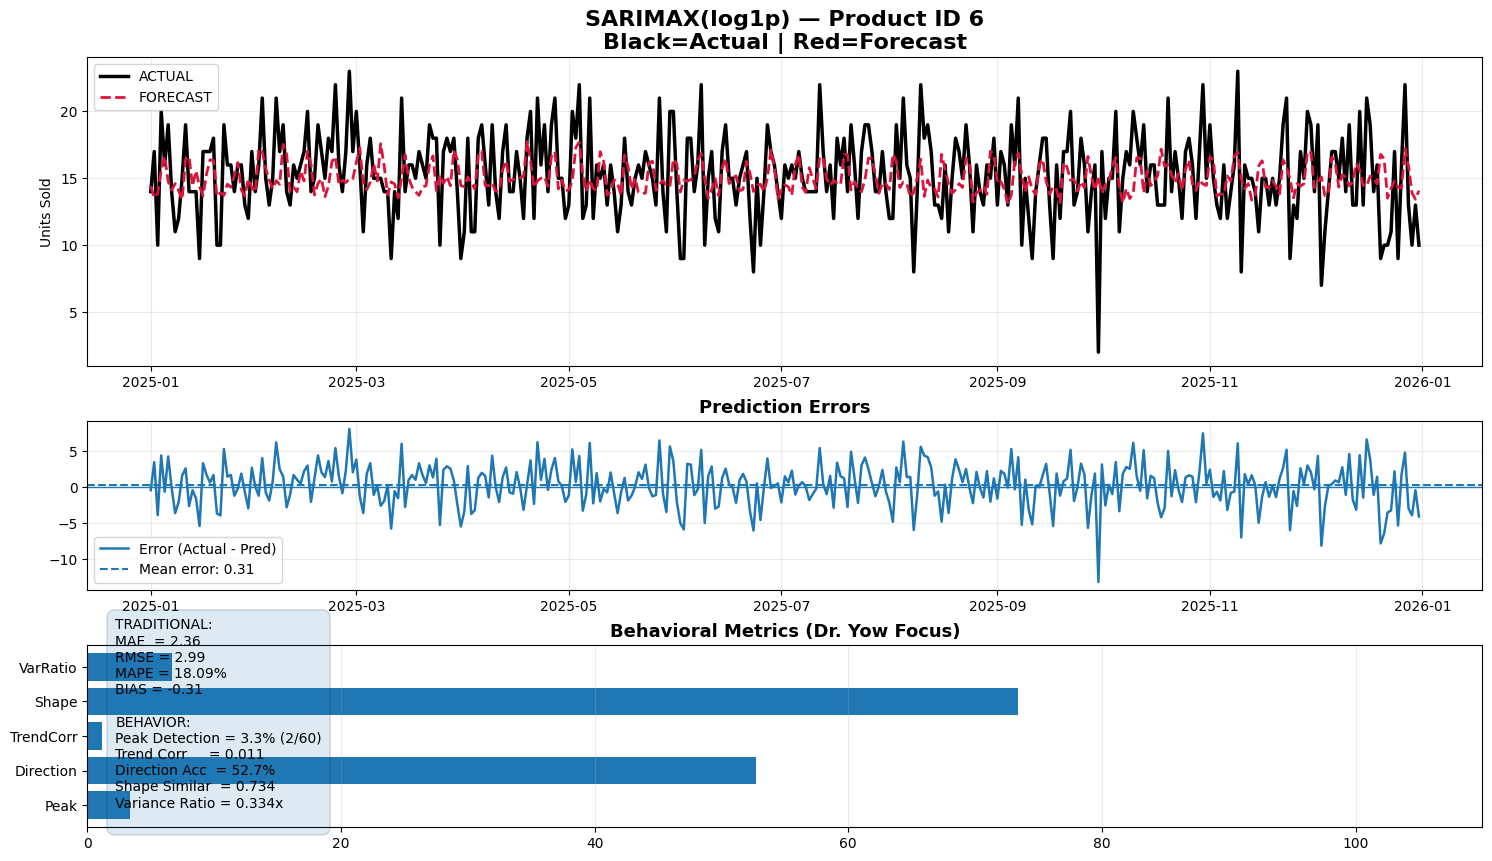

{'product_id': 6, 'model': 'SARIMAX(log1p)', 'diagnostics': {'n_days': 3288, 'n_nonzero_days': 3288, 'zero_rate': 0.0, 'max_zero_streak': 0}, 'mae': 2.3619605460033837, 'rmse': np.float64(2.989929049297185), 'mape': np.float64(18.09224850975809), 'bias': -0.3063284975117767, 'peak_detection_rate': 0.03333333333333333, 'n_peaks_real': 60, 'n_peaks_detected': 2, 'trend_correlation': np.float64(0.011317959936258075), 'direction_accuracy': np.float64(0.5274725274725275), 'shape_similarity': np.float64(0.7340057013654006), 'variance_ratio': 0.3338604122223079, 'pred_std': 1.0607874169676783, 'true_std': 3.1773381273528503}


In [36]:
from data.database.db_connection import get_connection

conn = get_connection()
try:
    selected_product_id = 6  # Resistance Bands Set
    out = run_pipeline(conn, product_id=selected_product_id, test_days=365)
    print(out)
finally:
    conn.close()

